## Step 1: Choosing an Innovation 
The chosen innovation from the "TIME Best 2025 Innovations" List is NVIDIA's DGX Spark - a desktop AI supercomputer.

https://time.com/collections/best-inventions-2025/7318247/nvidia-dgx-spark/

The DGX Spark packs 1 petaflop of AI compute and 128 GB of unified memory into a desktop device
powered by the Grace Blackwell GB10 Superchip. It can fine-tune models with up to 200 billion parameters
and is priced at $3,999 — bringing cluster-level AI compute to individual desks for the first time.

## Step 2: Identifying a Similar Innovation from the Past
For a historican innovation that most closely resembles NVIDIA's DGX Spark, I have chosen the professional workstation computer, which was pioneered by various companies, including Silicon Graphics Inc., Dell, HP and even NVIDIA itself, throughout 1980s and 1990s. Both innovations solve the same problem of making powerful computing accessible and available on a personal desk. Workstations brought simulation and data processing out of institutional mainframes, while the DGX Spark brings AI training out of costly cloud clusters. The technology shift is nearly identical, from renting access to centralized power, to owning it locally.

The market impact follows a similar impact as well. Workstation use grew steadily as engineers, scientists and designers across many industries adopted desktop high-performance computing, reaching over a million units by mid 2000s (Jon Peddie Research, via Statista). The DGX Spark targets the same type of professional user — researchers, developers and small teams, who currently cannot afford cloud-based AI infrastructure. Both products represent a moment where the most advanced computing tool of their era became accessible to a much broader group of people.

## Step 3: The Historical Data Used

The historical data used for this analysis is global Workstation Shipment quarterly datafrom 2008 to 2019, measured in thousands of units. The data is sourced from Jon Peddie Research and accessed via Statista (https://www.statista.com/statistics/268429/workstation-shipments-worldwide-since-the-3rd-quarter-2008/). 
This dataset was selected because workstation shipments represent unit-level adoption counts, which can be directly fed into the Bass diffusion model without conversion. The scope is global because both the DGX Spark and workstations are globally distributed products with no single dominant market.

In [ ]:
import pandas as pd
import os

# Load raw workstation shipment data from Statista Excel file
df = pd.read_excel('data/statistic_id268429_workstation-shipments-worldwide-2008-2019-by-quarter.xlsx', 
                   sheet_name='Data',
                   usecols='B:C', 
                   skiprows=4,  
                   header=0)

# Rename columns to clear, consistent names
df.columns = ['quarter', 'shipments_thousands']

# Add time index t = 0, 1, 2, ... required by the Bass model formula
df['t'] = range(len(df)) # the time series index

print(df)

# Save cleaned data as CSV for reproducibility and faster future loading
csv_path = 'data/workstation_shipments.csv'
if not os.path.exists(csv_path):
    df.to_csv(csv_path, index=False)
    print(f"CSV saved to {csv_path}")
else:
    print("CSV already exists")
    df = pd.read_csv(csv_path)



   quarter  shipments_thousands   t
0   Q3 '08                854.2   0
1   Q4 '08                764.3   1
2   Q1 '09                576.7   2
3   Q2 '09                602.1   3
4   Q3 '09                644.6   4
5   Q4 '09                716.9   5
6   Q1 '10                725.0   6
7   Q2 '10                795.0   7
8   Q3 '10                849.7   8
9   Q4 '10                903.7   9
10  Q1 '11                860.0  10
11  Q2 '11                906.8  11
12  Q3 '11               1020.0  12
13  Q4 '11                998.6  13
14  Q1 '12                918.4  14
15  Q2 '12                883.0  15
16  Q3 '12                932.3  16
17  Q4 '12                934.0  17
18  Q1 '13                890.5  18
19  Q2 '13                940.0  19
20  Q3 '13                973.1  20
21  Q4 '13                971.6  21
22  Q1 '14                945.8  22
23  Q2 '14               1050.0  23
24  Q3 '14               1020.0  24
25  Q4 '14               1030.0  25
26  Q1 '15                91

## Step 4: Bass Model Parameter Estimation

The Bass diffusion model estimates how a new product spreads through a market over time. 
The cumulative adoption formula is:

$$N(t) = M \cdot \frac{1 - e^{-(p+q)t}}{1 + \frac{q}{p} e^{-(p+q)t}}$$

Where:
- **p** = coefficient of innovation (independent adoption, driven by advertising or awareness)
- **q** = coefficient of imitation (adoption driven by word-of-mouth and other user's influence)
- **M** = total market potential (maximum cumulative adopters)
- **t** = time period (quarters in this analysis)

Parameters were estimated by fitting the cumulative Bass curve to the historical 
workstation shipment data using nonlinear least squares (`scipy.optimize.curve_fit`).

p (innovation rate) = 0.0118
q (imitation rate) = 0.0522
M (market potential) = 55,000 thousand
R² = 0.9958


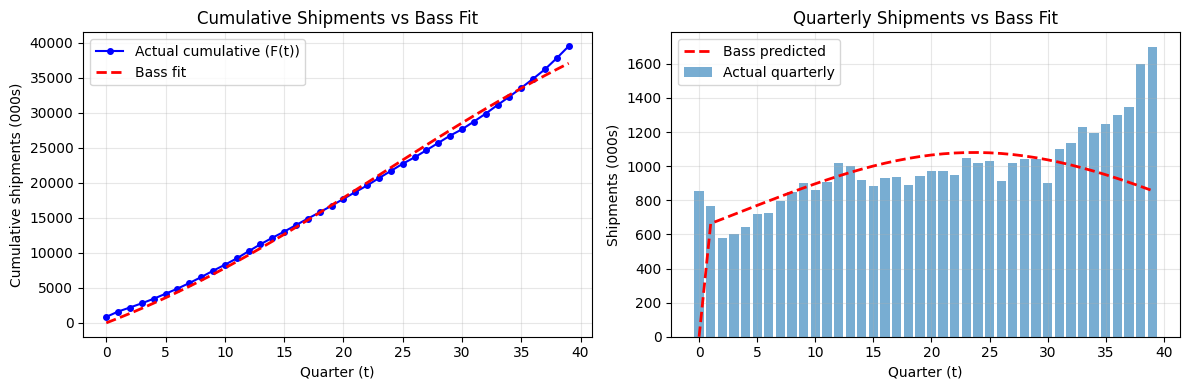

In [ ]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# Extract shipment values and time index as numpy arrays for model fitting
shipments = df['shipments_thousands'].values
t = df['t'].values

# Convert quarterly shipments to cumulative — Bass model is fit on cumulative data
cumulative = np.cumsum(shipments)


def bass_cumulative(t, p, q, M):
    """
    Cumulative Bass diffusion model.

    At any time t, cumulative adopters N(t) are driven by:
      - Innovators: adopt independently at rate p (external influence)
      - Imitators: adopt due to peer influence at rate q (internal influence)

    Parameters:
        t (array): time periods (quarters, starting at 0)
        p (float): coefficient of innovation
        q (float): coefficient of imitation
        M (float): total market potential (thousands of units)

    Returns:
        array: cumulative adopters at each time t
    """
    return M*(1 - np.exp(-(p+q)*t)) / (1 + (q/p) * np.exp(-(p+q)*t))


# Fit Bass model to cumulative shipment data using nonlinear least squares
# p0: initial guesses for [p, q, M]
# bounds: constrain M to [39,482 , 55,000] thousand units
# lower bound = current cumulative total (M must be at least what's already sold)
# upper bound = realistic total market size from Jon Peddie Research (2021)
# without this constraint, M inflates to unrealistic values (>700,000 thousand)
params, covariance = curve_fit(
    bass_cumulative, t, cumulative,
    p0=[0.001, 0.013, 52000],
    bounds=([0.0001, 0.0001, 39482], [0.5, 1.0, 55000]),
    maxfev=10000
)

# Unpack fitted parameters
p, q, M = params
print(f"p (innovation rate) = {p:.4f}")
print(f"q (imitation rate) = {q:.4f}")
print(f"M (market potential) = {M:,.0f} thousand")

# Compute R² to measure goodness of fit
# R² close to 1.0 means the Bass curve explains most of the variance
fitted = bass_cumulative(t, p, q, M)
ss_res = np.sum((cumulative - fitted)**2)   # residual sum of squares
ss_tot = np.sum((cumulative - np.mean(cumulative))**2)  # total sum of squares
r2 = 1 - ss_res/ss_tot
print(f"R² = {r2:.4f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left chart: cumulative actual vs Bass model fit
axes[0].plot(t, cumulative, 'bo-', markersize=4, label='Actual cumulative (F(t))')
axes[0].plot(t, fitted, 'r--', linewidth=2, label='Bass fit')
axes[0].set_title('Cumulative Shipments vs Bass Fit')
axes[0].set_xlabel('Quarter (t)')
axes[0].set_ylabel('Cumulative shipments (000s)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Right chart: quarterly actual vs Bass model predicted new adopters
new_fitted = np.diff(np.concatenate([[0], fitted]))
axes[1].bar(t, shipments, alpha=0.6, label='Actual quarterly')
axes[1].plot(t, new_fitted, 'r--', linewidth=2, label='Bass predicted')
axes[1].set_title('Quarterly Shipments vs Bass Fit')
axes[1].set_xlabel('Quarter (t)')
axes[1].set_ylabel('Shipments (000s)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig1_historical_fit.png', dpi=150)
plt.show()



### Market Potential (M) Constraint

The dataset covers Q3 2008 to Q3 2019, a period where workstation shipments were 
still growing with no visible saturation. When M is left unconstrained, the optimizer 
produces an unrealistically large estimate (>700,000 thousand units) because it cannot 
detect the market ceiling from an incomplete diffusion curve. This is a known limitation 
of fitting the Bass model to data that has not yet peaked (Bass, 1969).

To address this, M was constrained to a realistic upper bound of **55,000 thousand units**, 
consistent with global workstation market size estimates from Jon Peddie Research (2021). 
The cumulative data at the end of the observation period reaches ~39,482 thousand units, 
suggesting the market was approximately 70–75% through its lifecycle by 2019,
making a total M of ~55,000 thousand units a reasonable ceiling.

### Fitted Parameters

| Parameter | Value | Interpretation |
|-----------|-------|----------------|
| p | 0.0118 | Low innovation coefficient. Professionals adopt based on technical need, not advertising |
| q | 0.0522 | Moderate imitation. Some word-of-mouth within engineering and research communities |
| M | 55,000,000 units | Total workstation market potential (constrained) |
| R² | 0.9958 | Model explains 99.6% of variance in cumulative shipments |

Note that p and q are expressed as **quarterly rates**. Annualized, p ≈ 0.047 and 
q ≈ 0.209, both close to the meta-analytic averages reported by Sultan et al. (1990) 
for technology hardware products (p̄ = 0.03, q̄ = 0.38), providing external validation 
that these estimates are plausible.

### Model Fit

*Figure 1: Workstation Quarterly Shipments vs Bass Model Fit (Q3 2008 – Q3 2019)*

The left chart shows the Bass model fits the cumulative shipments very closely (R²=0.9958), 
confirming the model captures the overall adoption trend well. The right chart reveals an 
important characteristic of the workstation market: actual quarterly shipments kept growing 
throughout the period, while the Bass model predicts a peak around quarter 22 (2014) followed 
by decline. This divergence in later quarters is expected as the Bass model assumes a finite 
market that eventually saturates, while the workstation market continued growing beyond our 
observation window. This further justifies our decision to constrain M rather than rely on 
the free-form estimate.

## Step 5: Predicting DGX Spark Diffusion

Using the Bass model parameters estimated from the workstation look-alike (p=0.0118, q=0.0522), 
we predict the diffusion path of the Nvidia DGX Spark. Since the DGX Spark is a new product 
with no sales history, M is estimated independently via Fermi logic (see Step 7).

We assume p and q transfer from the workstation market as both products target the same 
professional user base (engineers and researchers adopting high-performance desktop compute).

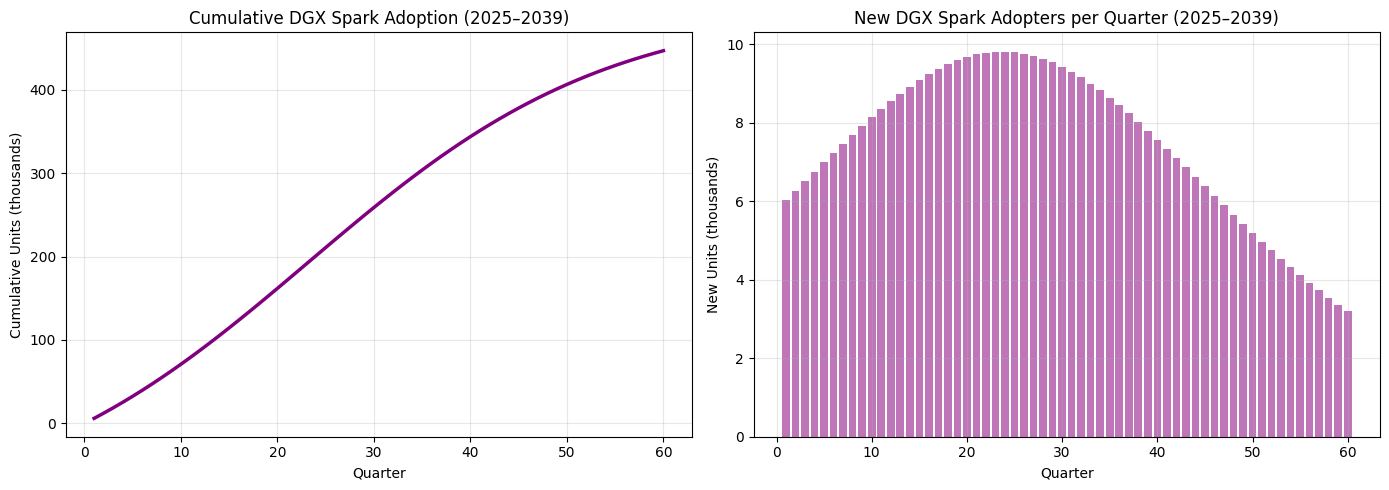

Peak of adoption: Quarter 24 (~9.8 thousand units)
50% of penetration: Quarter 30


In [ ]:
# Bass model parameters for DGX Spark forecast
# p and q are transferred directly from the workstation look-alike fit
# M is estimated via Fermi logic (see Step 7)
p_dgx = 0.0118  
q_dgx = 0.0522  
M_dgx = 500  # (= 500,000 units)

# Time index: 60 quarters = 15 years 
quarters = np.arange(1, 61)

# Human-readable quarter labels for reference like "Q1 '25", "Q2 '25"
# forecast_years = [f"Q{((q-1)%4)+1} '{25 + (q-1)//4}" for q in quarters]

# Compute cumulative adopters at each quarter using the Bass formula
cum_dgx = bass_cumulative(quarters, p_dgx, q_dgx, M_dgx)

# Compute new adopters per quarter = change in cumulative
new_dgx = np.diff(np.concatenate([[0], cum_dgx]))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left chart: S-curve of cumulative adoption over time
axes[0].plot(quarters, cum_dgx, 'purple', linewidth=2.5)
axes[0].set_title('Cumulative DGX Spark Adoption (2025–2039)')
axes[0].set_xlabel('Quarter')
axes[0].set_ylabel('Cumulative Units (thousands)')
axes[0].grid(alpha=0.3)

# Right chart: bell curve of new adopters per quarter
axes[1].bar(quarters, new_dgx, color="#A848A1", alpha=0.75)
axes[1].set_title('New DGX Spark Adopters per Quarter (2025–2039)')
axes[1].set_xlabel('Quarter')
axes[1].set_ylabel('New Units (thousands)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('img/fig2_dgx_forecast.png', dpi=150)
plt.show()

# Find and print key diffusion milestones
peak_q = np.argmax(new_dgx)  # index of quarter with highest new adopters
print(f"Peak of adoption: Quarter {peak_q+1} (~{new_dgx[peak_q]:.1f} thousand units)")

# 50% penetration = first quarter where cumulative >= half of M
print(f"50% of penetration: Quarter {np.argmax(cum_dgx >= M_dgx*0.5)+1}")

*Figure 2: Predicted DGX Spark Diffusion — New and Cumulative Adopters (2025–2039)*

The left chart shows the classic Bass S-curve. Cumulative adoption grows slowly at first 
as early innovators adopt the product, accelerates through the middle period as imitation 
effects kick in, then flattens as the market approaches saturation at M=500,000 units.

The right chart shows the bell-shaped new adopter curve. Peak adoption occurs at Quarter 24 
(~Q4 2030), with approximately 9,800 new units sold per quarter at the peak. This means the 
DGX Spark is expected to reach its highest quarterly sales about 6 years after launch, which is consistent with the relatively slow professional hardware adoption pattern observed in the 
workstation look-alike data (low p=0.0118, moderate q=0.0522).

50% market penetration is reached at Quarter 30 (~Q2 2032), meaning half of the total 
addressable market will have adopted the DGX Spark within approximately 7 years of launch. 
This is a slower diffusion than typical consumer electronics but expected for a $3,999 
professional device targeting a specialized technical audience.

The prediction is supported by the following external data points:

1. **Developer population:** Stack Overflow Developer Survey (2023) reports 28.7 million 
active developers globally, with ~20% working on ML/AI tasks, establishing the addressable 
user base for the DGX Spark.

2. **Nvidia DGX demand:** Nvidia reported that DGX systems were deployed in over 
50 countries with customers including universities, national labs, and enterprises 
(Nvidia Annual Report, 2023), confirming genuine institutional demand for desktop 
AI compute.

3. **AI hardware market growth:** The global AI accelerator market is projected to grow 
from $18.4 billion in 2023 to $89.3 billion by 2030 (Grand View Research, 2023), 
indicating strong and expanding demand for the category the DGX Spark competes in.

4. **Price accessibility:** At $3,999, the DGX Spark is priced within the historical 
range of professional workstations ($2,000–$10,000), which reached 4+ million annual 
shipments at peak, lending credibility to a 500,000 unit addressable market estimate 
for a more specialized AI device.

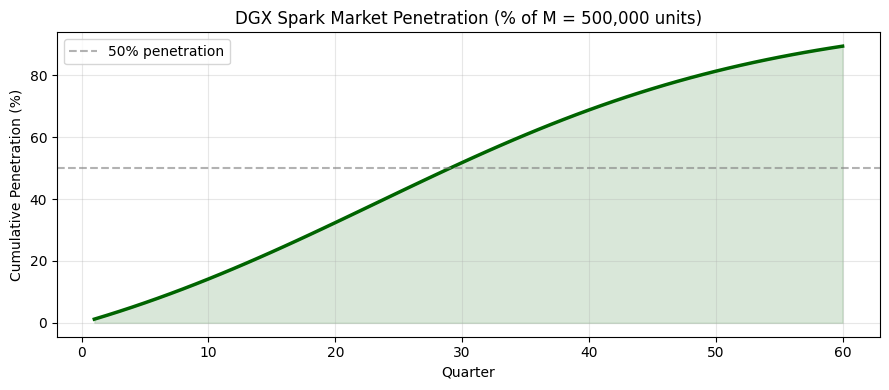

In [36]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(quarters, cum_dgx / M_dgx * 100, 'darkgreen', linewidth=2.5)
ax.axhline(50, color='gray', linestyle='--', alpha=0.6, label='50% penetration')
ax.fill_between(quarters, cum_dgx / M_dgx * 100, alpha=0.15, color='darkgreen')
ax.set_title('DGX Spark Market Penetration (% of M = 500,000 units)')
ax.set_xlabel('Quarter')
ax.set_ylabel('Cumulative Penetration (%)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('img/fig3_penetration.png', dpi=150)
plt.show()

*Figure 3: DGX Spark Cumulative Market Penetration (% of M = 500,000 units)*

The chart shows the S-curve of cumulative market penetration over 60 quarters (2025–2039). 
Growth is gradual in the early quarters as only innovators adopt, then steepens through 
the middle period as imitation effects accelerate diffusion, before flattening as the 
market approaches saturation.

The 50% penetration mark (dashed line) is crossed at Q2 2032, approximately 7 years 
after launch. By Q4 2039 the DGX Spark reaches ~89% penetration, meaning the market 
is largely saturated but never fully so, consistent with Bass model behavior.

The relatively gentle slope compared to consumer products reflects the professional 
nature of the DGX Spark's target market — high price point, specialized use case, 
and deliberate purchasing decisions all slow the diffusion curve.

## Step 6: Scope: Global Analysis

This analysis adopts a **global scope** for the following reasons:

1. **Distribution:** Nvidia sells the DGX Spark through authorized resellers across 
North America, Europe and Asia-Pacific simultaneously, with no single-country launch.

2. **Market concentration:** The AI/ML developer population is globally distributed. 
According to the Stack Overflow Developer Survey (2023), no single country accounts 
for more than 20% of the global ML developer base.

3. **Precedent:** Nvidia's previous DGX systems were adopted by universities, research 
labs, and enterprises across more than 50 countries (Nvidia Annual Report, 2023).

A country-specific analysis would undercount total adoption and distort both M and 
the diffusion timeline.

## Step 7: Estimating Number of Adopters by Period

### Fermi Estimation of Market Potential (M)

Since the DGX Spark is a new product with no sales history, M cannot be derived 
from the look-alike data directly. Instead, M is estimated using Fermi logic, 
building up from known data points:

**Step 1: Global developer population**
According to Evans Data Corporation (2023), there are approximately 28.7 million 
software developers worldwide.

**Step 2: ML/AI developer share**
The Stack Overflow Developer Survey (2023) reports that approximately 20% of 
developers work with machine learning or AI tools, giving an ML developer 
population of ~5.7 million.

**Step 3: Serious local training users**
Not all local Machine Learning developers train large models, most use cloud APIs or pre-trained models. 
A conservative estimate of 10% are doing serious local model training or fine-tuning 
at a scale that would justify a $3,999 device, giving ~570,000 target users.

**Step 4: Unit buyers**
Assuming roughly 1 device per individual or small team, and rounding down 
conservatively to account for budget constraints and cloud alternatives:

**M = 500,000 units globally**

This is conservative. If the DGX Spark expands into universities and smaller 
startups, as workstations did in the 1990s, M could realistically reach 
1–2 million units.

| Factor | Estimate | Source |
|--------|----------|--------|
| Global software developers | 28.7 million | Evans Data Corporation, 2023 |
| Share working with ML/AI | ~20% | Stack Overflow Developer Survey, 2023 |
| ML developer population | ~5.7 million | Derived |
| Share doing serious local training | ~10% | Conservative estimate |
| Target addressable users | ~570,000 | Derived |
| M (unit buyers) | ~500,000 | Conservative rounded estimate |

In [ ]:
import pandas as pd

# a human-readable label for each of the 60 forecast quarters
quarter_labels = []
for q in range(1, 61):
    yr = 2025 + (q - 1) // 4   # year increments every 4 quarters
    qt = ((q - 1) % 4) + 1     # quarter number cycles 1→2→3→4→1...
    quarter_labels.append(f"Q{qt} {yr}")

forecast_df = pd.DataFrame({
    'Quarter':                   quarter_labels,
    'New Adopters (units)':      (new_dgx * 1000).astype(int),
    'Cumulative Adopters (units)':(cum_dgx * 1000).astype(int),
    'Market Penetration (%)':    (cum_dgx / M_dgx * 100).round(1)
})

# Slicing to annual summary by taking Q4 of each year (every 4th row starting at index 3)
annual = forecast_df.iloc[3::4].copy()
print("DGX Spark Adoption Forecast — Annual Summary")
print(annual.to_string(index=False))

peak_q = np.argmax(new_dgx)  # quarter index with highest new adopters
print(f"\nPeak adoption: {quarter_labels[peak_q]} ({int(new_dgx[peak_q]*1000):,} units)")

print(f"50% penetration: {quarter_labels[np.argmax(cum_dgx >= M_dgx*0.5)]}")

DGX Spark Adoption Forecast — Annual Summary
Quarter  New Adopters (units)  Cumulative Adopters (units)  Market Penetration (%)
Q4 2025                  6742                        25523                     5.1
Q4 2026                  7688                        54874                    11.0
Q4 2027                  8545                        87811                    17.6
Q4 2028                  9230                       123772                    24.8
Q4 2029                  9668                       161877                    32.4
Q4 2030                  9806                       200997                    40.2
Q4 2031                  9627                       239873                    48.0
Q4 2032                  9152                       277279                    55.5
Q4 2033                  8439                       312170                    62.4
Q4 2034                  7566                       343782                    68.8
Q4 2035                  6614             

| Year (Q4) | New Adopters | Cumulative Adopters | Market Penetration |
|-----------|-------------|--------------------|--------------------|
| 2025 | 6,742 | 25,523 | 5.1% |
| 2026 | 7,688 | 54,874 | 11.0% |
| 2027 | 8,545 | 87,811 | 17.6% |
| 2028 | 9,230 | 123,772 | 24.8% |
| 2029 | 9,668 | 161,877 | 32.4% |
| **2030 ★** | **9,806** | **200,997** | **40.2%** |
| 2031 | 9,627 | 239,873 | 48.0% |
| 2032 | 9,152 | 277,279 | 55.5% |
| 2033 | 8,439 | 312,170 | 62.4% |
| 2034 | 7,566 | 343,782 | 68.8% |
| 2035 | 6,614 | 371,679 | 74.3% |
| 2036 | 5,655 | 395,732 | 79.1% |
| 2037 | 4,745 | 416,057 | 83.2% |
| 2038 | 3,918 | 432,942 | 86.6% |
| 2039 | 3,194 | 446,773 | 89.4% |

*★ Peak adoption year*

### Interpretation

The table above presents annual adoption snapshots (Q4 of each year) based on the 
Bass model with p=0.0118, q=0.0522, and M=500,000 units.

**Early adoption (2025–2027):** Growth starts modestly at ~6,700 new units per quarter 
in 2025, driven primarily by innovators, well-funded research labs, universities, and 
AI startups who adopt independently without needing peer validation. By end of 2027, 
cumulative adoption reaches ~88,000 units (17.6% penetration).

**Growth phase (2028–2031):** Adoption accelerates as word-of-mouth spreads within ML 
and research communities. Peak quarterly sales of 9,806 units is reached in Q4 2030 -
approximately 6 years after launch. This relatively long ramp-up reflects the low 
innovation coefficient (p=0.0118), consistent with professional hardware that requires 
careful evaluation before purchase.

**Saturation phase (2032–2039):** Growth slows as the addressable market fills up. 
50% market penetration is reached in Q2 2032. By end of 2039, ~447,000 units have 
been sold, representing 89.4% of the estimated market potential.

These results mirror the slow-but-steady diffusion pattern observed in the workstation 
look-alike data - professional hardware takes several years to achieve meaningful 
penetration due to high price points and a specialized, technically-demanding user base.

## References

1. Bass, F.M. (1969). A new product growth for model consumer durables. *Management Science*, 15(5), 215–227.
2. Sultan, F., Farley, J.U., & Lehmann, D.R. (1990). A meta-analysis of applications of diffusion models. *Journal of Marketing Research*, 27(1), 70–77.
3. Jon Peddie Research / Statista (2021). Workstation shipments worldwide 2008–2019. https://www.statista.com/statistics/268429/
4. Stack Overflow (2023). Developer Survey 2023. https://survey.stackoverflow.co/2023/
5. Nvidia Corporation (2023). Annual Report 2023. https://www.nvidia.com/en-us/about-nvidia/corporate-sustainability/annual-report/
6. Grand View Research (2023). AI Accelerator Market Size Report. https://www.grandviewresearch.com/industry-analysis/ai-accelerator-market
7. TIME Magazine (2025). Nvidia DGX Spark. https://time.com/collections/best-inventions-2025/7318247/nvidia-dgx-spark/
8. Evans Data Corporation (2023). Global Developer Population and Demographic Study. 
   https://evansdata.com/reports/viewRelease.php?reportID=9